# BERT for multi-label classification

We will be use the MyAnimeList 2020 dataset, which can be accessed on Kaggle. This dataset contains information about anime titles, ratings (from 1-10), and user preferences.

In [5]:
import pandas as pd

pre_merged_anime = pd.read_csv('pre_merged_anime.csv')
print(pre_merged_anime.shape)
pre_merged_anime.head(2)

(16206, 19)


,MAL_ID,Name,Score,Genres,English name,Type,Episodes,Premiered,Producers,Studios,Source,Duration,Rating,Ranked,Members,Favorites,Completed,On-Hold,synopsis
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,TV,26,Spring 1998,Bandai Visual,Sunrise,Original,24 min. per ep.,R - 17+ (violence & profanity),28.0,1251960,61971,718161,71513,"In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,Movie,1,Unknown,"Sunrise, Bandai Visual",Bones,Original,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,273145,1174,208333,1935,"other day, another bounty—such is the life of ..."


In [6]:
print(type(pre_merged_anime))

<class 'pandas.core.frame.DataFrame'>


In [7]:
import re
import string

def clean_text(text):
    # Remove non-printable characters
    text = ''.join(filter(lambda x: x in string.printable, text))
    # Replace multiple whitespace characters with a single space
    text = re.sub(r'\s{2,}', ' ', text).strip()
    return text.strip()

# WITH NO GENRES
def get_anime_description(anime_row):
    """
    Generates a custom description for an anime title based on various features from the input data.

    :param anime_row: A row from the MyAnimeList dataset containing relevant anime information.
    :return: A formatted string containing a custom description of the anime.
    """

    # Determine the type of anime (TV show or other)
    anime_type = "TV Show" if anime_row["Type"] == "TV" else anime_row["Type"]

    # Create a formatted description using the relevant features from the input data
    description = (
        f"{anime_row['Name']} is a {anime_type}.\n"
        f"Synopsis: {anime_row['synopsis']}\n"
        f"It was produced by {anime_row['Producers']} and it is from {anime_row['Studios']} Studio.\n"
        f"Its source is {anime_row['Source']}.\n"
        f"It premiered in {anime_row['Premiered']}."
    )

    return clean_text(description)


In [8]:
print(clean_text(get_anime_description(pre_merged_anime.iloc[0])))

Cowboy Bebop is a TV Show.
Synopsis: In the year 2071, humanity has colonized several of the planets and moons of the solar system leaving the now uninhabitable surface of planet Earth behind. The Inter Solar System Police attempts to keep peace in the galaxy, aided in part by outlaw bounty hunters, referred to as "Cowboys." The ragtag team aboard the spaceship Bebop are two such individuals. Mellow and carefree Spike Spiegel is balanced by his boisterous, pragmatic partner Jet Black as the pair makes a living chasing bounties and collecting rewards. Thrown off course by the addition of new members that they meet in their travelsEin, a genetically engineered, highly intelligent Welsh Corgi; femme fatale Faye Valentine, an enigmatic trickster with memory loss; and the strange computer whiz kid Edward Wongthe crew embarks on thrilling adventures that unravel each member's dark and mysterious past little by little. Well-balanced with high density action and light-hearted comedy, Cowboy Be

In [9]:
# Create a new column in our merged anime dataframe for our new descriptions
pre_merged_anime['generated_description'] = pre_merged_anime.apply(get_anime_description, axis=1)


In [10]:
from functools import reduce

all_genres = list(reduce(lambda y, z: y + z, pre_merged_anime['Genres'].map(lambda x: x.split(', '))))
all_genres[:3]

['Action', 'Adventure', 'Comedy']

<Axes: title={'center': 'Distribuion of Genres'}>

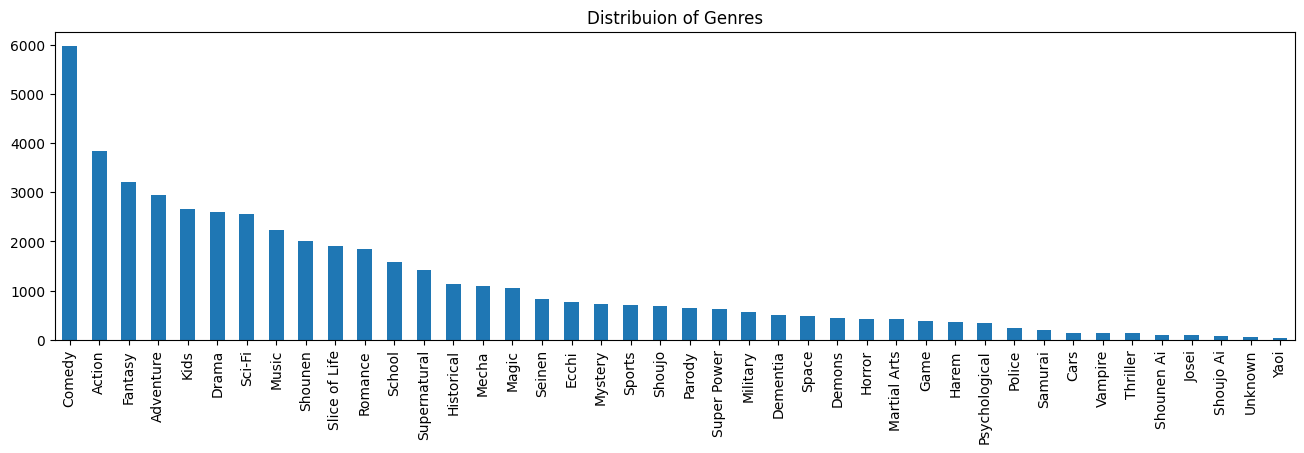

In [11]:
pd.Series(all_genres).value_counts().plot(kind='bar', title='Distribuion of Genres', figsize=(16, 4))

C:\Users\Wes\AppData\Local\Temp\ipykernel_27052\3669279515.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette=colors)
C:\Users\Wes\AppData\Local\Temp\ipykernel_27052\3669279515.py:16: UserWarning: 
The palette list has fewer values (10) than needed (42) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette=colors)


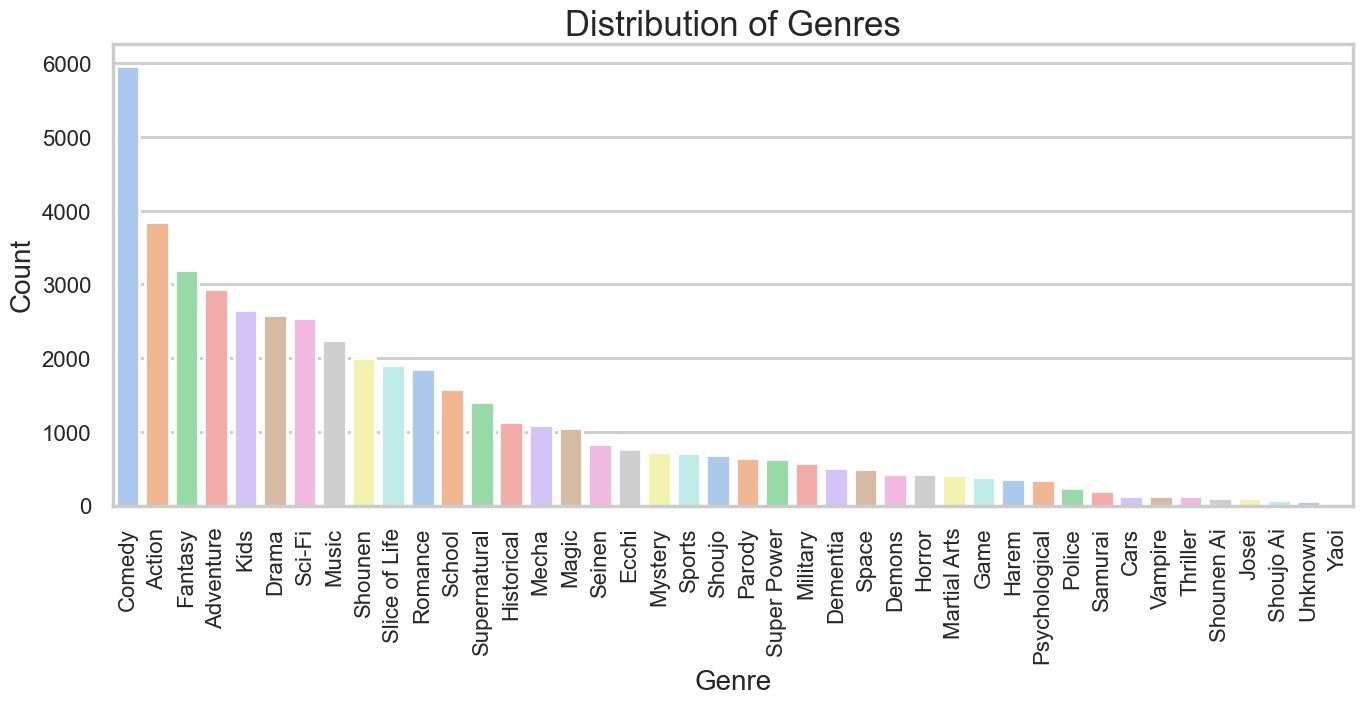

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style and context
sns.set_style('whitegrid')
sns.set_context('poster')  # Increase the base size of all fonts

# Prepare the data
genre_counts = pd.Series(all_genres).value_counts()

# Create the plot
plt.figure(figsize=(16, 6))

colors = sns.color_palette('pastel')[0:len(genre_counts)]
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette=colors)

plt.title('Distribution of Genres', fontsize=25)  # Increase fontsize for title
plt.xlabel('Genre', fontsize=20)  # Increase fontsize for x label
plt.ylabel('Count', fontsize=20)  # Increase fontsize for y label
plt.xticks(rotation=90, fontsize=16)  # Increase fontsize for x ticks
plt.yticks(fontsize=16)  # Increase fontsize for y ticks

# Show and save the plot
plt.savefig('genre_distribution.png', dpi=1000, bbox_inches='tight')
plt.show()


# Downsampling semantically similar texts

This can help consistency if our task is 'ill-defined' meaning that a similar input description yields different genres because the description doesn't have enough information for the model to distinguish between the genres

In [13]:
pip install -U sentence-transformers


   ---------------------------------------- 0.0/132.8 kB ? eta -:--:--
   ---------------------------------------- 132.8/132.8 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/991.5 kB ? eta -:--:--
   ------------------------- ------------- 655.4/991.5 kB 20.2 MB/s eta 0:00:01
   --------------------------------------- 991.5/991.5 kB 15.6 MB/s eta 0:00:00


In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Our model that encodes semantically similar texts to be near each other
downsample_model = SentenceTransformer('paraphrase-distilroberta-base-v1')
def filter_semantically_similar_texts(texts, similarity_threshold=0.8):
    # Generate embeddings for all texts. These embeddings are representations of
    # the texts in a high dimensional space, created in such a way that semantically
    # similar texts are close to each other in this space.
    embeddings = downsample_model.encode(texts)

    # Calculate the cosine similarity between all pairs of text embeddings. The
    # result is a matrix where the cell at the intersection of row i and column j
    # represents the cosine similarity between the embeddings of texts[i] and texts[j].
    similarity_matrix = cosine_similarity(embeddings)

    # Set the diagonal elements of the similarity matrix to 0, because they represent
    # the similarity of each text with itself, which is always 1.
    np.fill_diagonal(similarity_matrix, 0)

    # Initialize an empty list to store the texts that are not too similar to any
    # other text.
    filtered_texts = []

    # Initialize a set to store the indices of the texts that are too similar to
    # another text.
    excluded_indices = set()

    # For each text...
    for i, text in enumerate(texts):
        # If the current text is not too similar to any other text...
        if i not in excluded_indices:
            # Add it to the list of non-similar texts
            filtered_texts.append(text)

            # Find the indices of the texts that are too similar to the current text
            similar_texts_indices = np.where(similarity_matrix[i] > similarity_threshold)[0]

            # Exclude these texts from further consideration
            excluded_indices.update(similar_texts_indices)

    return filtered_texts

texts = [
    "This is a sample text.",
    "This is another sample text.",
    "This is a similar text.",
    "This is a completely different text.",
    "This text is quite alike.",
]

filtered_texts = filter_semantically_similar_texts(texts, similarity_threshold=0.9)
print(filtered_texts)


modules.json: 100%|███████████████████████████████████████████████████████████████████████████| 229/229 [00:00<?, ?B/s]
C:\Users\Wes\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Wes\.cache\huggingface\hub\models--sentence-transformers--paraphrase-distilroberta-base-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started

['This is a sample text.', 'This is a similar text.', 'This is a completely different text.', 'This text is quite alike.']


In [15]:
unique_labels = sorted(list(set(reduce(lambda y, z: y + z, pre_merged_anime['Genres'].map(lambda x: x.split(', '))))))

print(len(unique_labels), unique_labels)

42 ['Action', 'Adventure', 'Cars', 'Comedy', 'Dementia', 'Demons', 'Drama', 'Ecchi', 'Fantasy', 'Game', 'Harem', 'Historical', 'Horror', 'Josei', 'Kids', 'Magic', 'Martial Arts', 'Mecha', 'Military', 'Music', 'Mystery', 'Parody', 'Police', 'Psychological', 'Romance', 'Samurai', 'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shoujo Ai', 'Shounen', 'Shounen Ai', 'Slice of Life', 'Space', 'Sports', 'Super Power', 'Supernatural', 'Thriller', 'Unknown', 'Vampire', 'Yaoi']


In [16]:
id2label = {idx:label for idx, label in enumerate(unique_labels)}
label2id = {label:idx for idx, label in enumerate(unique_labels)}


In [17]:
pip install transformers

In [18]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

MODEL = 'distilbert-base-uncased'

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    problem_type="multi_label_classification",
    num_labels=len(unique_labels),
    id2label=id2label,
    label2id=label2id
)

config.json: 100%|████████████████████████████████████████████████████████████████████████████| 483/483 [00:00<?, ?B/s]
C:\Users\Wes\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Wes\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-developm

In [49]:
import numpy as np
import torch

tokenizer = AutoTokenizer.from_pretrained(MODEL)

def preprocess_data(examples, text_col):
    one_hot_encoded_matrix = []
    text = examples[text_col]
    genres = examples["Genres"]
    for genre in genres:
        g = genre.split(', ')
        one_hot_encoded_row = [1 if label in g else 0 for label in unique_labels]
        one_hot_encoded_matrix.append(one_hot_encoded_row)

    # Convert the one_hot_encoded_matrix to a LongTensor
    one_hot_encoded_matrix = [torch.tensor(o, dtype=torch.float32) for o in one_hot_encoded_matrix]

    # Encode the text
    encoding = tokenizer(text, truncation=True, max_length=256)
    # Add labels
    encoding["labels"] = one_hot_encoded_matrix
    return encoding


In [45]:
test_token = preprocess_data(anime_with_synopsis_dataset['train'][0], 'generated_description')

<class 'transformers.tokenization_utils_base.BatchEncoding'>


In [21]:
from datasets import Dataset
anime_with_synopsis_dataset = Dataset.from_pandas(pre_merged_anime[['synopsis', 'Genres', 'generated_description']])

anime_with_synopsis_dataset = anime_with_synopsis_dataset.train_test_split(test_size=.2, seed=42)

In [24]:
pre_merged_anime.head()

,MAL_ID,Name,Score,Genres,English name,Type,Episodes,Premiered,Producers,Studios,Source,Duration,Rating,Ranked,Members,Favorites,Completed,On-Hold,synopsis,generated_description
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,TV,26,Spring 1998,Bandai Visual,Sunrise,Original,24 min. per ep.,R - 17+ (violence & profanity),28.0,1251960,61971,718161,71513,"In the year 2071, humanity has colonized sever...",Cowboy Bebop is a TV Show.\nSynopsis: In the y...
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,Movie,1,Unknown,"Sunrise, Bandai Visual",Bones,Original,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,273145,1174,208333,1935,"other day, another bounty—such is the life of ...",Cowboy Bebop: Tengoku no Tobira is a Movie.\nS...
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,TV,26,Spring 1998,Victor Entertainment,Madhouse,Manga,24 min. per ep.,PG-13 - Teens 13 or older,266.0,558913,12944,343492,25465,"Vash the Stampede is the man with a $$60,000,0...",Trigun is a TV Show.\nSynopsis: Vash the Stamp...
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,TV,26,Summer 2002,"TV Tokyo, Bandai Visual, Dentsu, Victor Entert...",Sunrise,Original,25 min. per ep.,PG-13 - Teens 13 or older,2481.0,94683,587,46165,5121,ches are individuals with special powers like ...,Witch Hunter Robin is a TV Show.\nSynopsis: ch...
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,TV,52,Fall 2004,"TV Tokyo, Dentsu",Toei Animation,Manga,23 min. per ep.,PG - Children,3710.0,13224,18,7314,766,It is the dark century and the people are suff...,Bouken Ou Beet is a TV Show.\nSynopsis: It is ...


In [26]:
from tqdm.auto import tqdm
DOWNSAMPLE_TRAIN = True

def downsample_dataset(dataset, text_col, similarity_threshold=0.95):

    filtered_texts = filter_semantically_similar_texts(dataset[text_col], similarity_threshold)
    return [d for d in dataset if d[text_col] in filtered_texts]

if DOWNSAMPLE_TRAIN:
    anime_with_synopsis_dataset['train'] = Dataset.from_pandas(pd.DataFrame(
        downsample_dataset(anime_with_synopsis_dataset['train'], text_col='generated_description')
    ))


In [35]:
anime_with_synopsis_dataset['train'][0]

{'synopsis': 'Fifty years ago, malevolent stones known as Dark Brings brought about the "Overdrive," a calamitous event that destroyed one-tenth of the world. In the present day, the nefarious organization Demon Card seeks the Dark Brings\' power for their all but innocent intentions. Haru Glory, a sword-wielding silver-haired teenager, inherits the title of Rave Master: the person who wields the power of the legendary Rave Stones, artifacts capable of destroying the Dark Brings. However, the many Rave Stones were scattered across the globe as a result of the Overdrive, allowing Demon Card to continue their malpractices. Groove Adventure Rave follows Haru, his strange dog Plue, the fiery blonde Ellie, and the infamous thief Musica, as they embark on a great journey that will take them around the vast world, searching for the Rave Stones that will finally end Demon Card\'s injustice.',
 'Genres': 'Adventure, Comedy, Fantasy, Romance, Shounen',
 'generated_description': 'Groove Adventure

In [31]:
print(type(anime_with_synopsis_dataset))

<class 'datasets.dataset_dict.DatasetDict'>


In [50]:
description_encoded_dataset = anime_with_synopsis_dataset.map(
    lambda x: preprocess_data(x, 'generated_description'),
    batched=True, batch_size=128, remove_columns=['synopsis', 'Genres', 'generated_description']
)

description_encoded_dataset


Map: 100%|███████████████████████████████████████████████████████████████| 3242/3242 [00:00<00:00, 14545.22 examples/s]


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12843
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3242
    })
})

In [28]:
print(type(description_encoded_dataset))

<class 'datasets.dataset_dict.DatasetDict'>


In [ ]:
#description_encoded_dataset['train'][0]

{'input_ids': [101,
  14100,
  6172,
  23289,
  2003,
  1037,
  2694,
  2265,
  1012,
  19962,
  22599,
  1024,
  5595,
  2086,
  3283,
  1010,
  3287,
  6767,
  16136,
  6386,
  2124,
  2004,
  2601,
  7545,
  2716,
  2055,
  1996,
  1000,
  2058,
  23663,
  1010,
  1000,
  1037,
  10250,
  10631,
  24826,
  2015,
  2724,
  2008,
  3908,
  2028,
  1011,
  7891,
  1997,
  1996,
  2088,
  1012,
  1999,
  1996,
  2556,
  2154,
  1010,
  1996,
  11265,
  14971,
  6313,
  3029,
  5698,
  4003,
  11014,
  1996,
  2601,
  7545,
  1005,
  2373,
  2005,
  2037,
  2035,
  2021,
  7036,
  11174,
  1012,
  5292,
  6820,
  8294,
  1010,
  1037,
  4690,
  1011,
  26974,
  3165,
  1011,
  10681,
  10563,
  1010,
  22490,
  2015,
  1996,
  2516,
  1997,
  23289,
  3040,
  1024,
  1996,
  2711,
  2040,
  15536,
  14273,
  2015,
  1996,
  2373,
  1997,
  1996,
  8987,
  23289,
  6386,
  1010,
  10471,
  5214,
  1997,
  9846,
  1996,
  2601,
  7545,
  1012,
  2174,
  1010,
  1996,
  2116,
  23289,
  638

In [ ]:
# 1 - (12731/12964) == ~2% reduction in text

In [ ]:
# Import the necessary libraries
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from transformers import EvalPrediction
import torch
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, jaccard_score

# Define a function to compute several multi-label metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    # Initialize the sigmoid function which we'll use to transform our raw prediction values
    sigmoid = torch.nn.Sigmoid()

    # Apply sigmoid function to our predictions
    probs = sigmoid(torch.Tensor(predictions))

    # Create a binary prediction array based on our threshold
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1

    # Use actual labels as y_true
    y_true = labels

    # Compute F1 score, ROC AUC score, Accuracy, and Jaccard score
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    jaccard = jaccard_score(y_true, y_pred, average='micro')

    # Package the scores into a dictionary and return it
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy,
               'jaccard': jaccard}
    return metrics

# Define a function to compute metrics for predictions
def compute_metrics(p: EvalPrediction):
    # Extract the prediction values from the EvalPrediction object
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions

    # Compute the multi-label metrics for the predictions and actual labels
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)

    # Return the results
    return result


In [ ]:
#pip install transformers[torch] or pip install accelerate -U

Python versions and getting a higher version

In [ ]:
#!apt-get update -y

In [ ]:
#!apt-get install python3.8 python3.8-distutils

In [ ]:
#!update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.8 1

In [ ]:
#!update-alternatives --config python3

In [ ]:
#!apt-get install python3-pip
#!python3 -m pip install --upgrade pip --user

Installing pytorch

In [ ]:
#!pip3 uninstall --yes torch torchaudio torchvision torchtext torchdata
#!pip3 install torch torchaudio torchvision torchtext torchdata

In [ ]:
pip install transformers[torch]

In [ ]:
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)  #dynamic padding

In [ ]:


args = TrainingArguments(
    f"genre-prediction",
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,  # effective batch size of 64
    per_device_eval_batch_size=64,
    num_train_epochs=10,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="jaccard",
)

trainer = Trainer(
    model,
    args,
    train_dataset=description_encoded_dataset["train"],
    eval_dataset=description_encoded_dataset["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.evaluate()


You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


{'eval_loss': 0.693766713142395,
 'eval_f1': 0.1518648139806184,
 'eval_roc_auc': 0.561308074259148,
 'eval_accuracy': 0.0,
 'eval_jaccard': 0.08217191855305427,
 'eval_runtime': 23.5908,
 'eval_samples_per_second': 137.426,
 'eval_steps_per_second': 2.162}

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy,Jaccard
0,0.199000,0.192249,0.205877,0.558256,0.046885,0.114751
1,0.169100,0.162726,0.379641,0.623544,0.116286,0.234294
2,0.146300,0.149121,0.470116,0.665229,0.140654,0.307288
4,0.111700,0.139004,0.563871,0.722495,0.164713,0.392633
5,0.099100,0.139116,0.583725,0.739190,0.176434,0.412155
6,0.088500,0.139205,0.587333,0.739756,0.176743,0.415762
8,0.075800,0.141284,0.601847,0.752595,0.184146,0.430458
9,0.073900,0.141048,0.605431,0.753880,0.188155,0.434135


TrainOutput(global_step=2000, training_loss=0.1249827811717987, metrics={'train_runtime': 2932.9992, 'train_samples_per_second': 43.788, 'train_steps_per_second': 0.682, 'total_flos': 8277196209411096.0, 'train_loss': 0.1249827811717987, 'epoch': 9.96})

# WITH FREEZING

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    problem_type="multi_label_classification",
    num_labels=len(unique_labels),
    id2label=id2label,
    label2id=label2id
)

# Freeze everything up until the final 3 encoder layers
for name, param in model.named_parameters():
    if 'distilbert.transformer.layer.4' in name:
        break
    param.requires_grad = False


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    f"genre-prediction",
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=64,
    num_train_epochs=10,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="jaccard",
)

trainer = Trainer(
    model,
    args,
    train_dataset=description_encoded_dataset["train"],
    eval_dataset=description_encoded_dataset["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.evaluate()

{'eval_loss': 0.694111704826355,
 'eval_f1': 0.13688805318648847,
 'eval_roc_auc': 0.527107269957498,
 'eval_accuracy': 0.0,
 'eval_jaccard': 0.07347280093426953,
 'eval_runtime': 23.0486,
 'eval_samples_per_second': 140.659,
 'eval_steps_per_second': 2.213}

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy,Jaccard
0,0.199800,0.191041,0.205287,0.558093,0.044109,0.114384
1,0.172000,0.163016,0.374104,0.620963,0.111043,0.230091
2,0.156600,0.151556,0.457457,0.661063,0.125848,0.296560
4,0.139900,0.142473,0.511218,0.689507,0.147131,0.343380
5,0.133800,0.140363,0.527205,0.699064,0.155460,0.357962
6,0.128400,0.139595,0.537156,0.705107,0.152992,0.367200
8,0.123600,0.137605,0.556359,0.719546,0.161937,0.385386
9,0.123200,0.137261,0.553996,0.716762,0.162554,0.383122


TrainOutput(global_step=2000, training_loss=0.15198426127433776, metrics={'train_runtime': 1750.9305, 'train_samples_per_second': 73.35, 'train_steps_per_second': 1.142, 'total_flos': 8277196209411096.0, 'train_loss': 0.15198426127433776, 'epoch': 9.96})

In [ ]:
trainer.save_model()

In [ ]:
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL)

trained_model = AutoModelForSequenceClassification.from_pretrained(
    f"genre-prediction", problem_type="multi_label_classification",
).eval()  # without eval, dropout layers randomly cut off neurons making the output non deterministic

classifier = pipeline(
    "text-classification",model=trained_model, tokenizer=tokenizer,
    return_all_scores=True
)


In [ ]:
import random
random_animes = pre_merged_anime.sample(3)
texts = list(random_animes['generated_description'])
labels = list(random_animes['Genres'])


In [ ]:
prediction = classifier(texts)
THRESHOLD = 0.5

prediction = [[label for label in p if label['score'] > THRESHOLD] for p in prediction]

for _text, scores, label in zip(texts, prediction, labels):
    print(_text)
    print('------------')
    for _score in sorted(scores, key=lambda x: x['score'], reverse=True):
        print(f'{_score["label"]}: {_score["score"]*100:.2f}%')

    print('actual labels: ', label)
    print('------------')
